In [1]:
import os
import glob
import pandas as pd

# 1. Klasör yolunu kontrol et (Senin klasör ismin neyse onu yaz)
path = "E-Commerce Dataset" 
all_files = glob.glob(os.path.join(path, "*.csv"))

# 2. Dosyaları en baştan oku ve birleştir
df_list = []
for filename in all_files:
    temp_df = pd.read_csv(filename)
    category_name = os.path.basename(filename).replace(".csv", "")
    temp_df['category'] = category_name
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

print(f"VERİ GERİ GELDİ! Toplam satır: {len(df)}")

VERİ GERİ GELDİ! Toplam satır: 2000


In [2]:
# A. Önce 'final_price' sütununu metne (string) çevirelim (Hata almamak için şart)
df['final_price'] = df['final_price'].astype(str)

# B. Sadece rakamları ve noktayı tut, diğer her şeyi sil (Regex)
df['final_price'] = df['final_price'].str.replace(r'[^\d.]', '', regex=True)

# C. Boş kalan (string olarak '') hücreleri gerçek NaN yapalım
import numpy as np
df['final_price'] = df['final_price'].replace('', np.nan)

# D. Şimdi sayıya çevir
df['final_price'] = pd.to_numeric(df['final_price'], errors='coerce')

# E. SONUÇ KONTROLÜ (Dropna yapmadan önce kaç satırımız var?)
print(f"Sayıya çevirme sonrası dolu satır sayısı: {df['final_price'].notnull().sum()}")

# F. Eğer dolu satır varsa şimdi dropna yapabilirsin
df = df.dropna(subset=['final_price'])

print(f"Final satır sayısı: {len(df)}")
df.head()

Sayıya çevirme sonrası dolu satır sayısı: 2000
Final satır sayısı: 2000


,product_id,title,product_description,rating,ratings_count,initial_price,discount,final_price,currency,images,...,amount_of_stars,what_customers_said,seller_name,sizes,videos,seller_information,variations,best_offer,more_offers,category
0,8376765,Lino Perros,Women Navy Blue Solid Backpack,3.8,15,3995.0,58.0,3995.0,INR,http://assets.myntassets.com/assets/images/837...,...,"{""1_star"":2,""2_stars"":0,""3_stars"":3,""4_stars"":...",NaN,NaN,"[{""size"":""Onesize""}]","[""rw-8376765_cae700""]",NaN,[{}],{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
1,9136281,Tommy Hilfiger,Unisex Navy Blue Striped Backpack,4.5,67,2899.0,35.0,2899.0,INR,http://assets.myntassets.com/assets/images/913...,...,"{""1_star"":3,""2_stars"":4,""3_stars"":2,""4_stars"":...",NaN,NaN,"[{""size"":""Onesize""}]","[""rw-9136281_cae700""]",NaN,"[{},{}]",{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
2,17633752,Lavie,Aries Women Pink Mini Backpack,4.4,226,2999.0,65.0,2999.0,INR,http://assets.myntassets.com/assets/images/176...,...,"{""1_star"":9,""2_stars"":5,""3_stars"":10,""4_stars""...",NaN,NaN,"[{""size"":""S""}]","[""https://videos.myntassets.com/assets/videos/...",NaN,"[{},{},{},{},{},{}]",{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
3,1376949,F Gear,Unisex Navy & Grey Printed Burner Backpack,4.4,1052,1675.0,52.0,1675.0,INR,http://assets.myntassets.com/assets/images/137...,...,"{""1_star"":33,""2_stars"":21,""3_stars"":69,""4_star...",NaN,NaN,"[{""size"":""Onesize""}]","[""https://videos.myntassets.com/assets/videos/...",NaN,NaN,{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
4,13939916,MYTRIDENT,Men Blue Solid Bath Robe,4.7,12,2899.0,17.0,2899.0,INR,http://assets.myntassets.com/assets/images/pro...,...,"{""1_star"":0,""2_stars"":0,""3_stars"":0,""4_stars"":...",NaN,NaN,"[{""size"":""M"",""value"":""45.0in"",""value_name"":""Fr...",NaN,NaN,"[{},{},{},{},{},{},{},{},{},{},{},{},{},{}]",{},"[{""offer_name"":""10% Instant Discount on IndusI...",bath-robe


In [3]:
df.describe()

,product_id,rating,ratings_count,initial_price,discount,final_price
count,2.000000e+03,2000.000000,2000.000000,2000.000000,1758.000000,2000.000000
mean,1.713437e+07,3.621500,76.691000,2723.241000,53.503982,1706.096000
std,3.812812e+06,1.374057,241.053946,2408.094809,18.024070,1783.418227
min,5.868460e+05,0.000000,0.000000,249.000000,1.000000,199.000000
25%,1.511501e+07,3.700000,7.000000,1399.000000,44.000000,649.000000
50%,1.820890e+07,4.100000,17.000000,1999.000000,56.000000,1099.000000
75%,1.902737e+07,4.300000,58.000000,3299.000000,66.000000,2082.250000
max,2.274707e+07,5.000000,4441.000000,22199.000000,88.000000,17995.000000


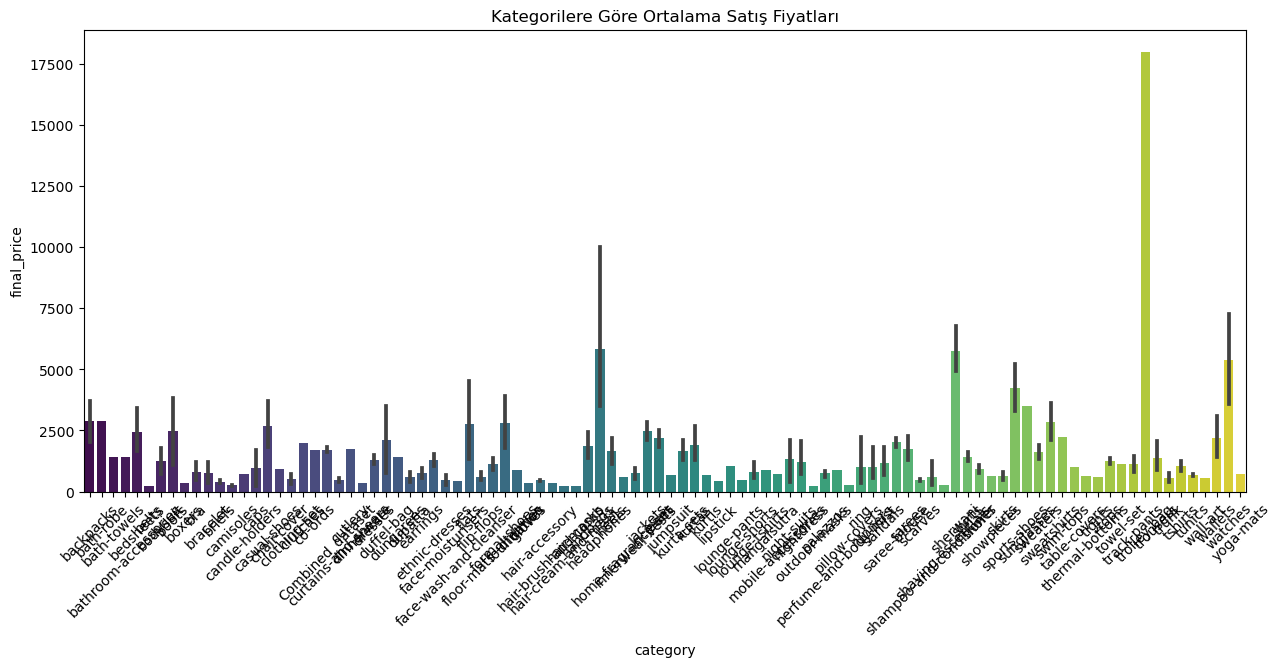

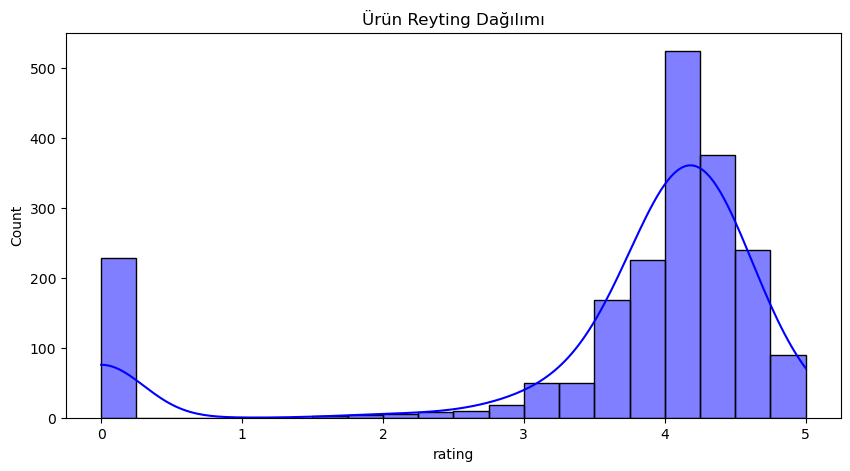

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Kategorilere Göre Ortalama Fiyatlar
plt.figure(figsize=(15,6))
sns.barplot(x='category', y='final_price', data=df, palette='viridis', estimator='mean')
plt.xticks(rotation=45)
plt.title('Kategorilere Göre Ortalama Satış Fiyatları')
plt.show()

# 2. Reyting Dağılımı (Müşteriler ürünleri nasıl puanlamış?)
plt.figure(figsize=(10,5))
sns.histplot(df['rating'], bins=20, kde=True, color='blue')
plt.title('Ürün Reyting Dağılımı')
plt.show()

In [5]:
# Korelasyon matrisi (Fiyat artınca reyting artıyor mu?)
# Korelasyon katsayısı r ile ifade edilir: -1 <= r <= 1
correlation = df[['final_price', 'rating', 'discount']].corr()
print("Korelasyon Analizi:\n", correlation)

# En karlı (en pahalı ortalamaya sahip) ilk 3 kategoriyi bulalım
top_expensive = df.groupby('category')['final_price'].mean().sort_values(ascending=False).head(3)
print("\nEn Pahalı Kategoriler:\n", top_expensive)

Korelasyon Analizi:
              final_price    rating  discount
final_price     1.000000  0.084587 -0.067643
rating          0.084587  1.000000 -0.135823
discount       -0.067643 -0.135823  1.000000

En Pahalı Kategoriler:
 category
trolley-bag    17995.000000
headphones      5832.333333
sherwani        5764.600000
Name: final_price, dtype: float64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Önce modelde kullanacağımız sütunları bir araya getirelim ve boş olanları silelim
# Bu işlem sadece bu 3 sütunda veri olan satırları tutar
df_model = df[['final_price', 'rating', 'discount']].dropna()

# 2. Şimdi X (Özellikler) ve y (Hedef) değişkenlerini bu temiz tablodan seçelim
X = df_model[['rating', 'discount']]
y = df_model['final_price']

# 3. Veriyi Eğitim ve Test olarak bölelim
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Modeli Oluştur ve Eğit
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Tahmin Yap ve Sonuçları Yazdır
y_pred = model.predict(X_test)

print(f"Model için kullanılan toplam satır sayısı: {len(df_model)}")
print(f"Model Başarı Skoru (R2): {model.score(X_test, y_test):.4f}")
print(f"Ortalama Hata (MAE): {mean_absolute_error(y_test, y_pred):.2f} Birim")

Model için kullanılan toplam satır sayısı: 1758
Model Başarı Skoru (R2): 0.0070
Ortalama Hata (MAE): 977.36 Birim


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Model için gerekli sütunları seçip boş olanları temizleyelim
df_model = df[['final_price', 'rating', 'discount']].dropna()

X = df_model[['rating', 'discount']]
y = df_model['final_price']

# 2. Eğitim ve Test setlerine bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Modeli Eğitme
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Tahmin ve Değerlendirme
y_pred = model.predict(X_test)

print(f"Kullanılan Ürün Sayısı: {len(df_model)}")
print(f"Model Skoru (R2): {model.score(X_test, y_test):.4f}")
print(f"Ortalama Hata (MAE): {mean_absolute_error(y_test, y_pred):.2f} ₹")

Kullanılan Ürün Sayısı: 1758
Model Skoru (R2): 0.0070
Ortalama Hata (MAE): 977.36 ₹


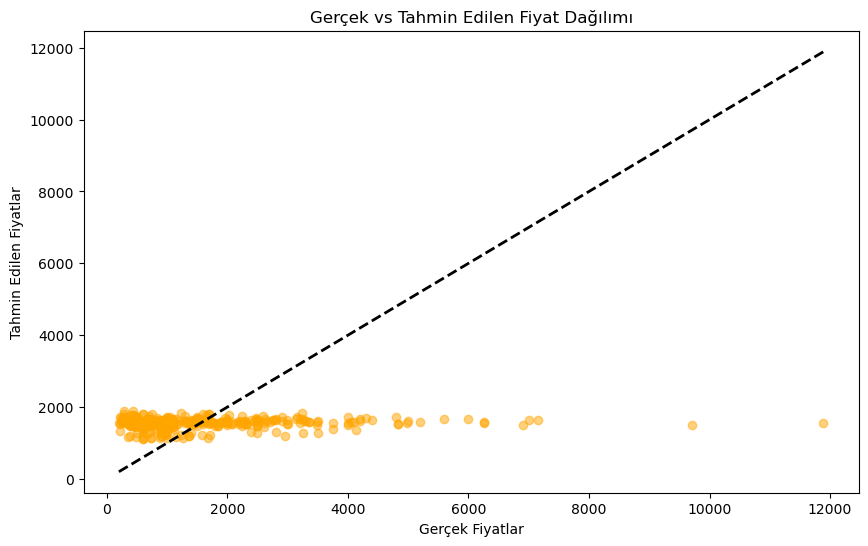

In [8]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # İdeal çizgi
plt.xlabel('Gerçek Fiyatlar')
plt.ylabel('Tahmin Edilen Fiyatlar')
plt.title('Gerçek vs Tahmin Edilen Fiyat Dağılımı')
plt.show()